## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

# For AddaBoost

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Travel.csv')
df.head(4)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0


In [6]:
df.info()#to print informationof tthe DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [7]:
#To cheack the valucount of ther object datatype
valueCount= [features for features in df.columns if df[features].dtype=='O']
for i in valueCount:
    print(f'{df[i].value_counts()}\n')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64



In [8]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus']=df['MaritalStatus'].replace('Unmarried','Single')

In [9]:
#To cheack the valucount of ther object datatype
valueCount= [features for features in df.columns if df[features].dtype=='O']
for i in valueCount:
    print(f'{df[i].value_counts()}\n')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

Gender
Male      2916
Female    1972
Name: count, dtype: int64

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64



In [10]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [11]:
df.drop('CustomerID',axis=1,inplace=True)

In [12]:
df['totalVisit']=df['NumberOfChildrenVisiting']+df['NumberOfPersonVisiting']

In [13]:
df.drop(columns=['NumberOfChildrenVisiting','NumberOfPersonVisiting'],axis=1,inplace=True)

In [14]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,totalVisit
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,NaN,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [15]:
null_features = [features for features in df.columns if df[features].isnull().sum()>=1]
for features in null_features:
    print(features,np.round(df[features].isnull().mean()*100,5),'%messing values')

Age 4.62357 %messing values
TypeofContact 0.51146 %messing values
DurationOfPitch 5.13502 %messing values
NumberOfFollowups 0.92062 %messing values
PreferredPropertyStar 0.53191 %messing values
NumberOfTrips 2.86416 %messing values
MonthlyIncome 4.76678 %messing values
totalVisit 1.35025 %messing values


## Imputing Null values
1. Impute Median value for Age column
2. Impute Mode for Type of Contract
3. Impute Median for Duration of Pitch
4. Impute Mode for NumberofFollowup as it is Discrete feature
5. Impute Mode for PreferredPropertyStar
6. Impute Median for NumberofTrips
7. Impute Mode for NumberOfChildrenVisiting
8. Impute Median for MonthlyIncome

In [16]:
df.Age.fillna(df.Age.median(),inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)
df.totalVisit.fillna(df.totalVisit.mode()[0],inplace=True)



In [17]:
numerical_features=[features for features in df.columns if df[features].dtype!='O']



In [18]:
catagorical_features = [feature for feature in df.columns if df[feature].dtype=='O']

In [19]:
descrete_numeric_feature = [features for features in numerical_features if len(df[features].unique())<=25]
continues_num_feature=[features for features in numerical_features if features not in descrete_numeric_feature]

In [20]:
print(f' 1: Numerical_feature:{len(numerical_features)}\n 2: Catogrical_feature:{len(catagorical_features)}\n 3: Descrete feature:{len(descrete_numeric_feature)}\n 4: Continous_feature:{len(continues_num_feature)}')

 1: Numerical_feature:12
 2: Catogrical_feature:6
 3: Descrete feature:9
 4: Continous_feature:3


In [21]:
X=df.drop('ProdTaken',axis=1,)
y=df['ProdTaken']

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=41)

In [23]:
numer_feat = X.select_dtypes(exclude='object').columns
catagorical_feat=X.select_dtypes(include='object').columns

In [24]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
Numeric_trans = StandardScaler()
cat_trans = OneHotEncoder(drop='first')

preprocess = ColumnTransformer(
    [
        ('onehotIncoder',cat_trans,catagorical_feat),
        ('StandSclr',Numeric_trans,numer_feat)
    ]
)

In [25]:
X_train = preprocess.fit_transform(X_train)

X_test = preprocess.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [27]:
def model_evel(true,predict):
    acc_sc = accuracy_score(true,predict)
    f1_scor = f1_score(true,predict)
    prec_scor = precision_score(true,predict)
    recall_sc = recall_score(true,predict)
    roc_scoe = roc_auc_score(true,predict)
    return acc_sc,f1_scor,prec_scor,recall_sc,roc_scoe


In [34]:
models ={
    'LogisticRegression':LogisticRegression(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomforestClassifer':RandomForestClassifier(),
    'AdaBoostClassifier':AdaBoostClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    #make prediction
    Tain_pred = model.predict(X_train)
    Test_pred= model.predict(X_test)

    train_acc,train_f1,train_preci,train_rec,train_roc=model_evel(y_train,Tain_pred)
    test_acc,test_f1,test_preci,test_rec,test_roc=model_evel(y_test,Test_pred)
    print(list(models.keys())[i])

    print('Model preformance Training Prediction ')
    print('accuracy:{:.4f}'.format(train_acc))
    print('F1 score:{:.4f}'.format(train_f1))
    print('precision:{:.4f}'.format(train_preci))
    print('recall score:{:.4f}'.format(train_rec))
    print('roc_auc_score:{:.4f}'.format(train_roc))
    
    print('----------------------------------------------------')

    print('Model preformance Test Prediction ')
    print('accuracy:{:.4f}'.format(test_acc))
    print('F1 score:{:.4f}'.format(test_f1))
    print('precision:{:.4f}'.format(test_preci))
    print('recall score:{:.4f}'.format(test_rec))
    print('roc_auc_score:{:.4f}'.format(test_roc))

    print('====================================================')
    print('\n')

LogisticRegression
Model preformance Training Prediction 
accuracy:0.8459
F1 score:0.4378
precision:0.7051
recall score:0.3175
roc_auc_score:0.6433
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8494
F1 score:0.4177
precision:0.7416
recall score:0.2907
roc_auc_score:0.6338


KNeighborsClassifier
Model preformance Training Prediction 
accuracy:0.9408
F1 score:0.8254
precision:0.9327
recall score:0.7403
roc_auc_score:0.8639
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8871
F1 score:0.6230
precision:0.8201
recall score:0.5022
roc_auc_score:0.7385


DecisionTreeClassifier
Model preformance Training Prediction 
accuracy:1.0000
F1 score:1.0000
precision:1.0000
recall score:1.0000
roc_auc_score:1.0000
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.9198
F1 score:0.7832
precision:0.7867
recall score:0.7797
roc_auc_score:0.8657


Randomfore

## class DecisionTreeClassifier(
    *,
    criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
    splitter: Literal['best', 'random'] = "best",
    max_depth: Int | None = None,
    min_samples_split: float = 2,
    min_samples_leaf: float = 1,
    min_weight_fraction_leaf: Float = 0,
    max_features: float | Literal['auto', 'sqrt', 'log2'] | None = None,
    random_state: Int | RandomState | None = None,
    max_leaf_nodes: Int | None = None,
    min_impurity_decrease: Float = 0,
    class_weight: Mapping | str | Sequence[Mapping] | None = None,
    ccp_alpha: float = 0
## class RandomForestClassifier(
    n_estimators: Int = 100,
    *,
    criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
    max_depth: Int | None = None,
    min_samples_split: float = 2,
    min_samples_leaf: float = 1,
    min_weight_fraction_leaf: Float = 0,
    max_features: float | Literal['sqrt', 'log2'] = "sqrt",
    max_leaf_nodes: Int | None = None,
    min_impurity_decrease: Float = 0,
    bootstrap: bool = True,
    oob_score: bool = False,
    n_jobs: Int | None = None,
    random_state: Int | RandomState | None = None,
    verbose: Int = 0,
    warm_start: bool = False,
    class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
    ccp_alpha: float = 0,
    max_samples: float | None = None
)
## class AdaBoostClassifier(
    estimator: Any = None,
    *,
    n_estimators: Int = 50,
    learning_rate: Float = 1,
    algorithm: Literal['SAMME', 'SAMME.R'] = "SAMME.R",
    random_state: Int | RandomState | None = None,
    base_estimator: Any = "deprecated"

In [ ]:
Decision_tree_parem = {
   'criterion': ['gini', 'entropy', 'log_loss'] ,
   'splitter': ['best', 'random'],
   'max_depth':[1,2,3,4,5,14,25,20,25,50],
   'max_features':[1,2,3,4,5,6,10],
   'min_impurity_decrease': [1,2,3,4,5,6,7],
}
RandomForestparems={
   'n_estimators': [100,200,30,400,500,600,700,1500,2000],
   'criterion': ['gini', 'entropy', 'log_loss'] ,
   'max_depth':[1,2,3,4,5,6,7],
   'min_samples_split': [0.1,0.02,0.3,0.1,0.21,1.0],
    'min_samples_leaf':[ 1,2,3,4,5,6],
    'max_features': [1,2,3,4,5,6]   
}
Addaboost_parems={
    'n_estimators':[10,20,30,40,50,60,100],
    'learning_rate':[0.1,0.2,0.3,0.25,1.0],
    'algorithm': ['SAMME', 'SAMME.R']   
}


In [ ]:
randomcv_mod=[
    ('RF',RandomForestClassifier(),RandomForestparems),
    ('DT',DecisionTreeClassifier(),Decision_tree_parem),
    ('AB',AdaBoostClassifier(),Addaboost_parems)
]
from sklearn.model_selection import RandomizedSearchCV


In [47]:
parem_model={}
for name,model,parem in randomcv_mod:
    random=RandomizedSearchCV(
        estimator=model,
        param_distributions=parem,
        n_iter=100,
        cv=3,
        verbose=3,
        n_jobs=-1
    )
    random.fit(X_train,y_train)
    parem_model[name]=random.best_params_
for model_name in parem_model:
    print(f'___________________Best parems{model_name}______________')
    print(parem_model[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 70 candidates, totalling 210 fits
___________________Best paremsRF______________
{'n_estimators': 100, 'min_samples_split': 0.02, 'min_samples_leaf': 4, 'max_features': 6, 'max_depth': 7, 'criterion': 'gini'}
___________________Best paremsDT______________
{'splitter': 'random', 'min_impurity_decrease': 3, 'max_features': 5, 'max_depth': 3, 'criterion': 'gini'}
___________________Best paremsAB______________
{'n_estimators': 50, 'learning_rate': 1.0, 'algorithm': 'SAMME'}


In [48]:
models = {
    'RandomForestClassifier':RandomForestClassifier(n_estimators =100, min_samples_split= 0.02, min_samples_leaf= 4, max_features= 6, max_depth= 7, criterion= 'gini'),
    'DecisionTreeClassifier':DecisionTreeClassifier(splitter= 'random', min_impurity_decrease= 3, max_features=5, max_depth= 3, criterion= 'gini'),
    'AdaBoostClassifier':AdaBoostClassifier(n_estimators=50, learning_rate= 1.0, algorithm= 'SAMME')
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    train_acc,train_f1,train_preci,train_rec,train_roc=model_evel(y_train,Tain_pred)
    test_acc,test_f1,test_preci,test_rec,test_roc=model_evel(y_test,Test_pred)
    print(list(models.keys())[i])

    print('Model preformance Training Prediction ')
    print('accuracy:{:.4f}'.format(train_acc))
    print('F1 score:{:.4f}'.format(train_f1))
    print('precision:{:.4f}'.format(train_preci))
    print('recall score:{:.4f}'.format(train_rec))
    print('roc_auc_score:{:.4f}'.format(train_roc))
    
    print('----------------------------------------------------')

    print('Model preformance Test Prediction ')
    print('accuracy:{:.4f}'.format(test_acc))
    print('F1 score:{:.4f}'.format(test_f1))
    print('precision:{:.4f}'.format(test_preci))
    print('recall score:{:.4f}'.format(test_rec))
    print('roc_auc_score:{:.4f}'.format(test_roc))

    print('====================================================')
    print('\n')

    

RandomForestClassifier
Model preformance Training Prediction 
accuracy:0.8502
F1 score:0.4178
precision:0.7880
recall score:0.2843
roc_auc_score:0.6332
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8494
F1 score:0.3826
precision:0.8028
recall score:0.2511
roc_auc_score:0.6185


DecisionTreeClassifier
Model preformance Training Prediction 
accuracy:0.8502
F1 score:0.4178
precision:0.7880
recall score:0.2843
roc_auc_score:0.6332
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8494
F1 score:0.3826
precision:0.8028
recall score:0.2511
roc_auc_score:0.6185


AdaBoostClassifier
Model preformance Training Prediction 
accuracy:0.8502
F1 score:0.4178
precision:0.7880
recall score:0.2843
roc_auc_score:0.6332
----------------------------------------------------
Model preformance Test Prediction 
accuracy:0.8494
F1 score:0.3826
precision:0.8028
recall score:0.2511
roc_auc_score:0.6185




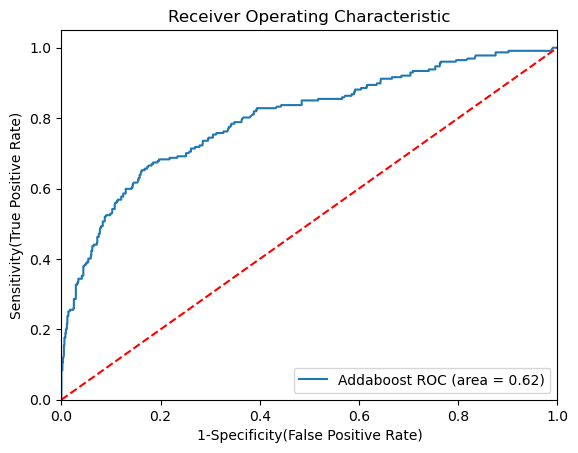

In [ ]:
plt.figure()
use_model=[
    {
        'Label':'Addaboost',
        'model':AdaBoostClassifier(n_estimators=50, learning_rate= 1.0, algorithm= 'SAMME'),
        'Auc_score':0.6185
    },
]
for algo in use_model:
    model = algo['model']
    model.fit(X_train,y_train)
    fpr ,tpr,treshold=roc_curve(y_test,model.predict_proba(X_test)[:,1])
    plt.plot(fpr,tpr,label='%s ROC (area = %0.2f)' % (algo['Label'], algo['Auc_score']))

plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("aucadna.png")
plt.show() 